In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, initializers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.datasets import make_classification
import warnings
import random
# import gzip
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

# Define a universal seed value
seed_value = 42

# 1. Set Python built-in random seed
random.seed(seed_value)

# 2. Set NumPy random seed
np.random.seed(seed_value)

# 3. Set TensorFlow/Keras random seed
tf.random.set_seed(seed_value)

# (Optional) Force TensorFlow to use deterministic operations
# This prevents slight variations caused by GPU multithreading
tf.config.experimental.enable_op_determinism()


TensorFlow version: 2.19.0


In [ ]:
# Generating synthetic dataset (Mimics HIGGS structure)
X, y = make_classification(
    n_samples=10000,
    n_features=28,
    n_informative=20,
    n_classes=2,
    random_state=42
)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Further split training into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Standardize features (crucial for this dataset)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"\nTraining samples: {X_train.shape[0]:,}")
print(f"Validation samples: {X_val.shape[0]:,}")
print(f"Testing samples: {X_test.shape[0]:,}")
print(f"Input features: {X_train.shape[1]}")



Training samples: 6,400
Validation samples: 1,600
Testing samples: 2,000
Input features: 28


In [ ]:
# ============================================================================
# SECTION 1: Simple Architecture (Baseline)
# ============================================================================

def create_simple_model(input_dim):
    """
    Simple architecture with minimal neurons and layers
    - 1 hidden layer with 8 neurons only
    - No batch normalization
    - No dropout
    - Basic initialization
    - This will struggle with complex HIGGS dataset
    """
    model = keras.Sequential([
        layers.Dense(8, activation='relu', input_dim=input_dim),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Create and compile simple model
simple_model = create_simple_model(X_train.shape[1])
simple_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nSimple Model Architecture:")
simple_model.summary()
print(f"\nTotal Parameters: {simple_model.count_params():,}")

# Train simple model
print("\nTraining Simple Model...")
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_simple = simple_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=512,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# Evaluate simple model
simple_loss, simple_acc = simple_model.evaluate(X_test, y_test, verbose=0)
simple_pred = (simple_model.predict(X_test, verbose=0) > 0.5).astype(int)

print(f"\n{'='*60}")
print(f"SIMPLE MODEL RESULTS:")
print(f"{'='*60}")
print(f"Test Accuracy: {simple_acc:.4f} ({simple_acc*100:.2f}%)")
print(f"Test Loss: {simple_loss:.4f}")




Simple Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)


Total Parameters: 241

Training Simple Model...
Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.4967 - loss: 0.8490 - val_accuracy: 0.5163 - val_loss: 0.8016
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5178 - loss: 0.7927 - val_accuracy: 0.5325 - val_loss: 0.7530
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5444 - loss: 0.7444 - val_accuracy: 0.5638 - val_loss: 0.7115
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5706 - loss: 0.7031 - val_accuracy: 0.6019 - val_loss: 0.6762
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6016 - loss: 0.6680 - val_accuracy: 0.6288 - val_loss: 0.6458
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6259 - loss: 0.6379 - val_accuracy: 0.6519 - val_loss: 0.6196
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6541 - loss: 0.6118 - val_accuracy: 0.6769 - val_loss: 0.5966
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy:

In [ ]:
# Dictionary to store results
results = {
    'Simple Model (8 neurons)': simple_acc
}
histories = {
    'Simple Model': history_simple
}


In [ ]:
# ============================================================================
# SECTION 2: Complex Architecture with Progressive Improvements
# ============================================================================

print("\n" + "="*80)
print("ARCHITECTURE 2: COMPLEX MODEL WITH PROGRESSIVE ENHANCEMENTS")
print("="*80)


# -------------------------------------------
# 2.1: Large Architecture (No extras)
# -------------------------------------------
print("\n[Step 2.1] Large Architecture (More layers, more neurons, no extras)")

def create_large_model(input_dim):
    """
    Large architecture with more layers and neurons
    - 5 hidden layers: 256 -> 128 -> 64 -> 32 -> 16 neurons
    - No batch normalization
    - No dropout
    """
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_dim=input_dim),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

large_model = create_large_model(X_train.shape[1])
large_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print(f"\nLarge Model Parameters: {large_model.count_params():,}")

history_large = large_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=512,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

large_loss, large_acc = large_model.evaluate(X_test, y_test, verbose=0)
results['Large Model (256→16)'] = large_acc
histories['Large Model'] = history_large
print(f"\n✓ Large Model Test Accuracy: {large_acc:.4f} ({large_acc*100:.2f}%)")
print(f"  Improvement over simple: {(large_acc - simple_acc)*100:.2f}%")



ARCHITECTURE 2: COMPLEX MODEL WITH PROGRESSIVE ENHANCEMENTS

[Step 2.1] Large Architecture (More layers, more neurons, no extras)

Large Model Parameters: 51,201
Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.6422 - loss: 0.6246 - val_accuracy: 0.8231 - val_loss: 0.4937
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8722 - loss: 0.3863 - val_accuracy: 0.9087 - val_loss: 0.2597
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9317 - loss: 0.1960 - val_accuracy: 0.9488 - val_loss: 0.1494
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9631 - loss: 0.1160 - val_accuracy: 0.9631 - val_loss: 0.1130
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9745 - loss: 0.0861 - val_accuracy: 0.9737 - val_loss: 0.0956
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9839 - loss: 0.0652 - val_accuracy: 0.9731 - val_loss: 0.0898
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9883 - los

In [ ]:
# -------------------------------------------
# 2.2: Large Architecture + Batch Normalization
# -------------------------------------------
print("\n[Step 2.2] Large Architecture + Batch Normalization")

def create_model_with_batchnorm(input_dim):
    """Add Batch Normalization after each dense layer"""
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_dim=input_dim),
        layers.BatchNormalization(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(16, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

bn_model = create_model_with_batchnorm(X_train.shape[1])
bn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print(f"BatchNorm Model Parameters: {bn_model.count_params():,}")

history_bn = bn_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=512,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

bn_loss, bn_acc = bn_model.evaluate(X_test, y_test, verbose=0)
results['Large + BatchNorm'] = bn_acc
histories['BatchNorm'] = history_bn
print(f"\n✓ BatchNorm Model Test Accuracy: {bn_acc:.4f} ({bn_acc*100:.2f}%)")
print(f"  Improvement over large: {(bn_acc - large_acc)*100:.2f}%")



[Step 2.2] Large Architecture + Batch Normalization
BatchNorm Model Parameters: 53,185
Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.7480 - loss: 0.5243 - val_accuracy: 0.7588 - val_loss: 0.6311
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9264 - loss: 0.2487 - val_accuracy: 0.9006 - val_loss: 0.5473
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9580 - loss: 0.1702 - val_accuracy: 0.9244 - val_loss: 0.4627
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9745 - loss: 0.1212 - val_accuracy: 0.9225 - val_loss: 0.3934
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9850 - loss: 0.0896 - val_accuracy: 0.9137 - val_loss: 0.3457
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9902 - loss: 0.0682 - val_accuracy: 0.9125 - val_loss: 0.3094
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9939 - loss: 0.0530 - val_accuracy: 0.9106 - val_loss: 0.2790
Epoch 8/30
13/13 ━━━━━━

In [ ]:
# -------------------------------------------
# 2.3: Large Architecture + Different Initializations
# -------------------------------------------
print("\n[Step 2.3] Large Architecture + Different Weight Initializations")

initialization_results = {}

# Test different initializers
init_techniques = {
    'He Normal': initializers.HeNormal(),
    'He Uniform': initializers.HeUniform(),
    'Xavier Normal': initializers.GlorotNormal(),
    'Xavier Uniform': initializers.GlorotUniform(),
    'LeCun Normal': initializers.LecunNormal()
}

for init_name, init_fn in init_techniques.items():
    print(f"\nTesting {init_name} initialization...")

    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_dim=X_train.shape[1],
                    kernel_initializer=init_fn),
        layers.Dense(128, activation='relu', kernel_initializer=init_fn),
        layers.Dense(64, activation='relu', kernel_initializer=init_fn),
        layers.Dense(32, activation='relu', kernel_initializer=init_fn),
        layers.Dense(16, activation='relu', kernel_initializer=init_fn),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=512,
        validation_data=(X_val, y_val),
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
        verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    initialization_results[init_name] = acc
    print(f"  {init_name:20s} Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# Store best initialization result
best_init = max(initialization_results, key=initialization_results.get)
results[f'Large + {best_init}'] = initialization_results[best_init]
print(f"\n✓ Best Initialization: {best_init} with accuracy {initialization_results[best_init]:.4f}")



[Step 2.3] Large Architecture + Different Weight Initializations

Testing He Normal initialization...
  He Normal            Test Accuracy: 0.9710 (97.10%)

Testing He Uniform initialization...
  He Uniform           Test Accuracy: 0.9665 (96.65%)

Testing Xavier Normal initialization...
  Xavier Normal        Test Accuracy: 0.9745 (97.45%)

Testing Xavier Uniform initialization...
  Xavier Uniform       Test Accuracy: 0.9725 (97.25%)

Testing LeCun Normal initialization...
  LeCun Normal         Test Accuracy: 0.9740 (97.40%)

✓ Best Initialization: Xavier Normal with accuracy 0.9745


In [ ]:
# -------------------------------------------
# 2.4: Large Architecture + Dropout
# -------------------------------------------
print("\n[Step 2.4] Large Architecture + Dropout Regularization")

def create_model_with_dropout(input_dim, dropout_rate=0.3):
    """Add Dropout layers for regularization"""
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_dim=input_dim),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(16, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

dropout_model = create_model_with_dropout(X_train.shape[1])
dropout_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_dropout = dropout_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=512,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

dropout_loss, dropout_acc = dropout_model.evaluate(X_test, y_test, verbose=0)
results['Large + Dropout (0.3)'] = dropout_acc
histories['Dropout'] = history_dropout
print(f"\n✓ Dropout Model Test Accuracy: {dropout_acc:.4f} ({dropout_acc*100:.2f}%)")



[Step 2.4] Large Architecture + Dropout Regularization
Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.5691 - loss: 0.6777 - val_accuracy: 0.8087 - val_loss: 0.6262
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7002 - loss: 0.5891 - val_accuracy: 0.8363 - val_loss: 0.4382
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8030 - loss: 0.4593 - val_accuracy: 0.8662 - val_loss: 0.3204
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8606 - loss: 0.3646 - val_accuracy: 0.9119 - val_loss: 0.2462
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8933 - loss: 0.2961 - val_accuracy: 0.9331 - val_loss: 0.1888
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9125 - loss: 0.2531 - val_accuracy: 0.9463 - val_loss: 0.1518
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9323 - loss: 0.2105 - val_accuracy: 0.9663 - val_loss: 0.1204
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - ac

In [ ]:
# -------------------------------------------
# 2.5: Large Architecture + Different Optimizers
# -------------------------------------------
print("\n[Step 2.5] Large Architecture + Different Optimizers")

optimizer_results = {}

# Test different optimizers
optimizers_to_test = {
    'Adam': optimizers.Adam(learning_rate=0.001),
    'SGD + Momentum': optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': optimizers.RMSprop(learning_rate=0.001),
    'Adagrad': optimizers.Adagrad(learning_rate=0.01),
    'AdamW': optimizers.AdamW(learning_rate=0.001) # Add AdamW if available/needed
}

# Reuse the large model architecture for consistency
def create_model_for_optimizer_test(input_dim):
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_dim=input_dim),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

for opt_name, optimizer_fn in optimizers_to_test.items():
    print(f"\nTesting {opt_name} optimizer...")

    model = create_model_for_optimizer_test(X_train.shape[1])
    model.compile(optimizer=optimizer_fn, loss='binary_crossentropy', metrics=['accuracy'])

    # Use same early stopping as before for fair comparison
    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=512,
        validation_data=(X_val, y_val),
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
        verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    optimizer_results[opt_name] = acc
    print(f"  {opt_name:20s} Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# Store best optimizer result
best_opt = max(optimizer_results, key=optimizer_results.get)
results[f'Large + {best_opt}'] = optimizer_results[best_opt]
print(f"\n✓ Best Optimizer: {best_opt} with accuracy {optimizer_results[best_opt]:.4f}")


# -------------------------------------------
# 2.6: Combined ALL Best Techniques in ONE Model
# -------------------------------------------
print("\n[Step 2.6] ULTIMATE MODEL - Combining ALL Best Techniques")
print("="*70)
print("This model combines EVERYTHING we learned:")
print(f"  ✓ Large Architecture (256→128→64→32→16)")
print(f"  ✓ Batch Normalization after each layer")
print(f"  ✓ Best Initialization: {best_init}")
print(f"  ✓ Dropout Regularization (0.3→0.2 progressive)")
print(f"  ✓ Best Optimizer: {best_opt}")
print(f"  ✓ Learning Rate Scheduling")
print("="*70)

def create_ultimate_model(input_dim):
    """
    ULTIMATE MODEL - Combines ALL best techniques:
    1. Large architecture with optimal neuron distribution
    2. Batch Normalization for training stability
    3. Best weight initialization
    4. Dropout for regularization (progressive rates)
    5. Will be trained with best optimizer + adaptive learning rate (ReduceLROnPlateau)
    """
    model = keras.Sequential([
        # First block - Largest layer
        layers.Dense(256, activation='relu', input_dim=input_dim,
                    kernel_initializer=init_techniques[best_init],
                    name='dense_1_256'),
        layers.BatchNormalization(name='bn_1'),
        layers.Dropout(0.3, name='dropout_1'),

        # Second block
        layers.Dense(128, activation='relu',
                    kernel_initializer=init_techniques[best_init],
                    name='dense_2_128'),
        layers.BatchNormalization(name='bn_2'),
        layers.Dropout(0.3, name='dropout_2'),

        # Third block
        layers.Dense(64, activation='relu',
                    kernel_initializer=init_techniques[best_init],
                    name='dense_3_64'),
        layers.BatchNormalization(name='bn_3'),
        layers.Dropout(0.2, name='dropout_3'),

        # Fourth block
        layers.Dense(32, activation='relu',
                    kernel_initializer=init_techniques[best_init],
                    name='dense_4_32'),
        layers.BatchNormalization(name='bn_4'),
        layers.Dropout(0.2, name='dropout_4'),

        # Fifth block
        layers.Dense(16, activation='relu',
                    kernel_initializer=init_techniques[best_init],
                    name='dense_5_16'),
        layers.BatchNormalization(name='bn_5'),
        layers.Dropout(0.1, name='dropout_5'),

        # Output layer
        layers.Dense(1, activation='sigmoid', name='output')
    ])
    return model

# Create the ultimate model
ultimate_model = create_ultimate_model(X_train.shape[1])

# Use the best optimizer with a fixed learning rate
# We'll use ReduceLROnPlateau callback for adaptive learning rate instead of schedule
# This avoids the conflict between LearningRateSchedule and ReduceLROnPlateau

# Recreate the best optimizer with fixed initial learning rate
if best_opt == 'Adam':
    ultimate_optimizer = optimizers.Adam(learning_rate=0.001)
elif best_opt == 'SGD + Momentum':
    ultimate_optimizer = optimizers.SGD(learning_rate=0.01, momentum=0.9)
elif best_opt == 'RMSprop':
    ultimate_optimizer = optimizers.RMSprop(learning_rate=0.001)
elif best_opt == 'Adagrad':
    ultimate_optimizer = optimizers.Adagrad(learning_rate=0.01)
else:  # AdamW
    ultimate_optimizer = optimizers.AdamW(learning_rate=0.001)

ultimate_model.compile(
    optimizer=ultimate_optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n" + "="*70)
print("ULTIMATE MODEL ARCHITECTURE:")
print("="*70)
ultimate_model.summary()
print(f"\nTotal Parameters: {ultimate_model.count_params():,}")
print(f"Trainable Parameters: {sum([tf.size(w).numpy() for w in ultimate_model.trainable_weights]):,}")

# Additional callbacks for better training
# ReduceLROnPlateau will adaptively reduce learning rate when validation loss plateaus
callbacks_ultimate = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7)
]

print("\n" + "="*70)
print("TRAINING ULTIMATE MODEL...")
print("="*70)

history_ultimate = ultimate_model.fit(
    X_train, y_train,
    epochs=50,  # More epochs since we have early stopping
    batch_size=512,
    validation_data=(X_val, y_val),
    callbacks=callbacks_ultimate,
    verbose=1
)

# Evaluate ultimate model
print("\n" + "="*70)
print("EVALUATING ULTIMATE MODEL...")
print("="*70)

ultimate_loss, ultimate_acc = ultimate_model.evaluate(X_test, y_test, verbose=1)
ultimate_pred = (ultimate_model.predict(X_test, verbose=0) > 0.5).astype(int)

# Store results
results['ULTIMATE (All Techniques)'] = ultimate_acc
histories['Ultimate'] = history_ultimate

# Print detailed comparison
print("\n" + "="*80)
print("ULTIMATE MODEL RESULTS")
print("="*80)
print(f"\n{'Metric':<30} {'Value'}")
print("-" * 50)
print(f"{'Test Accuracy':<30} {ultimate_acc:.4f} ({ultimate_acc*100:.2f}%)")
print(f"{'Test Loss':<30} {ultimate_loss:.4f}")
print(f"{'Improvement over Simple':<30} +{(ultimate_acc - simple_acc)*100:.2f}%")
print(f"{'Improvement over Large':<30} +{(ultimate_acc - large_acc)*100:.2f}%")
print(f"{'Improvement over BatchNorm':<30} +{(ultimate_acc - bn_acc)*100:.2f}%")
print(f"{'Improvement over Dropout':<30} +{(ultimate_acc - dropout_acc)*100:.2f}%")

print("\n" + "="*80)
print("COMPARISON WITH INDIVIDUAL TECHNIQUES")
print("="*80)
comparison_df = pd.DataFrame({
    'Model': [
        'Simple (Baseline)',
        'Large Architecture',
        'Large + BatchNorm Only',
        'Large + Dropout Only',
        f'Large + {best_init} Only',
        f'Large + {best_opt} Only',
        'ULTIMATE (All Combined)'
    ],
    'Accuracy': [
        simple_acc,
        large_acc,
        bn_acc,
        dropout_acc,
        initialization_results[best_init],
        optimizer_results[best_opt],
        ultimate_acc
    ]
})
comparison_df['Improvement %'] = ((comparison_df['Accuracy'] - simple_acc) * 100).round(2)
comparison_df['Accuracy'] = comparison_df['Accuracy'].round(4)
print(comparison_df.to_string(index=False))

print("\n" + "="*80)
print(f"🎯 ULTIMATE MODEL ACHIEVES: {ultimate_acc:.4f} ({ultimate_acc*100:.2f}%)")
print(f"🚀 TOTAL IMPROVEMENT: +{(ultimate_acc - simple_acc)*100:.2f}% over baseline")
print("="*80)



[Step 2.5] Large Architecture + Different Optimizers

Testing Adam optimizer...
  Adam                 Test Accuracy: 0.9735 (97.35%)

Testing SGD + Momentum optimizer...
  SGD + Momentum       Test Accuracy: 0.9720 (97.20%)

Testing RMSprop optimizer...
  RMSprop              Test Accuracy: 0.9760 (97.60%)

Testing Adagrad optimizer...
  Adagrad              Test Accuracy: 0.9640 (96.40%)

Testing AdamW optimizer...
  AdamW                Test Accuracy: 0.9755 (97.55%)

✓ Best Optimizer: RMSprop with accuracy 0.9760

[Step 2.6] ULTIMATE MODEL - Combining ALL Best Techniques
This model combines EVERYTHING we learned:
  ✓ Large Architecture (256→128→64→32→16)
  ✓ Batch Normalization after each layer
  ✓ Best Initialization: Xavier Normal
  ✓ Dropout Regularization (0.3→0.2 progressive)
  ✓ Best Optimizer: RMSprop
  ✓ Learning Rate Scheduling

ULTIMATE MODEL ARCHITECTURE:


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1_256 (Dense)             │ (None, 256)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2_128 (Dense)             │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3_64 (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4_32 (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5_16 (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_5 (BatchNormalization)       │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,185 (207.75 KB)

 Trainable params: 52,193 (203.88 KB)

 Non-trainable params: 992 (3.88 KB)


Total Parameters: 53,185
Trainable Parameters: 52,193

TRAINING ULTIMATE MODEL...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.6523 - loss: 0.6466 - val_accuracy: 0.7831 - val_loss: 0.6268 - learning_rate: 0.0010
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8033 - loss: 0.4325 - val_accuracy: 0.8931 - val_loss: 0.5327 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8705 - loss: 0.3265 - val_accuracy: 0.9200 - val_loss: 0.4235 - learning_rate: 0.0010
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8961 - loss: 0.2710 - val_accuracy: 0.9306 - val_loss: 0.3258 - learning_rate: 0.0010
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9123 - loss: 0.2295 - val_accuracy: 0.9312 - val_loss: 0.2589 - learning_rate: 0.0010
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9331 - loss: 0.1928 - val_accuracy: 0.9325 - val_loss: 0.2187 - learning_rate: 0.0010
Epoch 7/50



FINAL RESULTS COMPARISON

Progressive Improvement Results:
Model Configuration                      Accuracy     Improvement
----------------------------------------------------------------------
Simple Model (8 neurons)                 0.8550 (85.50%)  +0.00%
Large Model (256→16)                     0.9720 (97.20%)  +11.70%
Large + BatchNorm                        0.9730 (97.30%)  +11.80%
Large + Xavier Normal                    0.9745 (97.45%)  +11.95%
Large + Dropout (0.3)                    0.9785 (97.85%)  +12.35%
Large + RMSprop                          0.9760 (97.60%)  +12.10%
ULTIMATE (All Techniques)                0.9815 (98.15%)  +12.65%


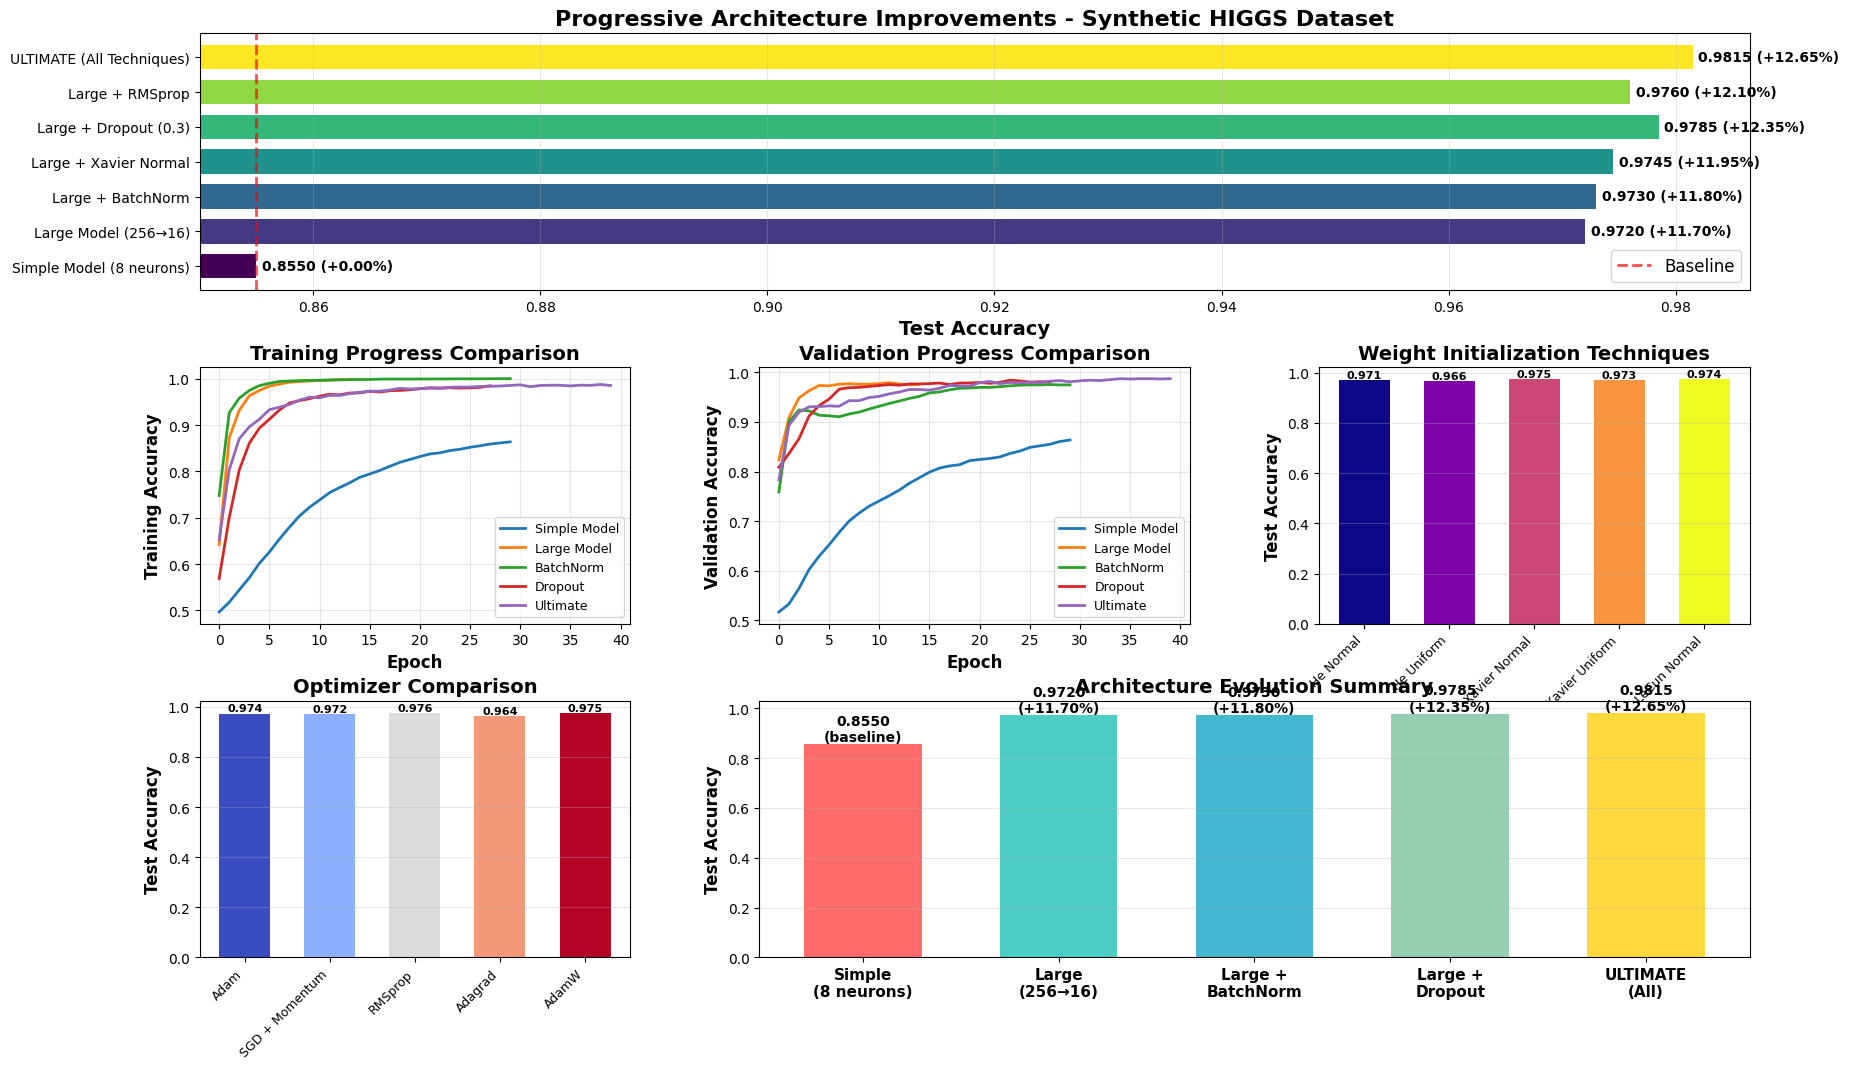


SUMMARY STATISTICS

Baseline (Simple Model) Accuracy: 0.8550 (85.50%)
Best Model Accuracy: 0.9815 (98.15%)
Absolute Improvement: 0.1265
Relative Improvement: 14.80%

Improvement Breakdown:
  Size Increase            : +11.70%
  Batch Normalization      : +0.10%
  Dropout                  : +0.65%
  Combined Techniques      : +0.95%

KEY FINDINGS

1. Architecture Complexity Impact:
 - Simple model (8 neurons): 85.50%
 - Large model (256→16): 97.20% (+11.70%)
 - Clear demonstration that deeper/wider networks learn better representations

2. Batch Normalization:
 - Improved accuracy by 0.10%
 - Stabilizes training and allows faster convergence

3. Weight Initialization:
 - Best: Xavier Normal (97.45%)
 - Worst: He Uniform (96.65%)
 - Difference: 0.80%

4. Dropout Regularization:
 - Improved generalization by 0.65%
 - Helps prevent overfitting on this complex dataset

5. Optimizer Selection:
 - Best: RMSprop (97.60%)
 - Worst: Adagrad (96.40%)
 - Significant impact on convergence speed an

In [ ]:
  # ============================================================================
# SECTION 3: Comprehensive Comparison and Visualization
# ============================================================================

print("\n" + "="*80)
print("FINAL RESULTS COMPARISON")
print("="*80)

# Display all results
print("\nProgressive Improvement Results:")
print(f"{'Model Configuration':<40} {'Accuracy':<12} {'Improvement'}")
print("-" * 70)
baseline = results['Simple Model (8 neurons)']
for model_name, acc in results.items():
    improvement = (acc - baseline) * 100
    print(f"{model_name:<40} {acc:.4f} ({acc*100:.2f}%)  +{improvement:.2f}%")

# Create comprehensive comparison plots
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Progressive Improvements Comparison (Large)
ax1 = fig.add_subplot(gs[0, :])
models = list(results.keys())
accuracies = list(results.values())
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

bars = ax1.barh(models, accuracies, color=colors, height=0.7)
ax1.set_xlabel('Test Accuracy', fontsize=14, fontweight='bold')
ax1.set_title('Progressive Architecture Improvements - Synthetic HIGGS Dataset', fontsize=16, fontweight='bold')
ax1.set_xlim([min(accuracies) - 0.005, max(accuracies) + 0.005])

for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    improvement = (acc - baseline) * 100
    ax1.text(acc + 0.0005, i, f'{acc:.4f} (+{improvement:.2f}%)',
            va='center', fontweight='bold', fontsize=10)

ax1.axvline(x=baseline, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Baseline')
ax1.legend(fontsize=12)
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Training History Comparison
ax2 = fig.add_subplot(gs[1, 0])
for name, history in histories.items():
    if 'accuracy' in history.history:
        ax2.plot(history.history['accuracy'], label=name, linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Training Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Training Progress Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# Plot 3: Validation History Comparison
ax3 = fig.add_subplot(gs[1, 1])
for name, history in histories.items():
    if 'val_accuracy' in history.history:
        ax3.plot(history.history['val_accuracy'], label=name, linewidth=2)
ax3.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax3.set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
ax3.set_title('Validation Progress Comparison', fontsize=14, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# Plot 4: Initialization Techniques Comparison
ax4 = fig.add_subplot(gs[1, 2])
init_names = list(initialization_results.keys())
init_accs = list(initialization_results.values())
colors2 = plt.cm.plasma(np.linspace(0, 1, len(init_names)))

bars2 = ax4.bar(range(len(init_names)), init_accs, color=colors2, width=0.6)
ax4.set_xticks(range(len(init_names)))
ax4.set_xticklabels(init_names, rotation=45, ha='right', fontsize=9)
ax4.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
ax4.set_title('Weight Initialization Techniques', fontsize=14, fontweight='bold')

for bar, acc in zip(bars2, init_accs):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.0002,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=8)

ax4.grid(axis='y', alpha=0.3)

# Plot 5: Optimizer Comparison
ax5 = fig.add_subplot(gs[2, 0])
opt_names = list(optimizer_results.keys())
opt_accs = list(optimizer_results.values())
colors3 = plt.cm.coolwarm(np.linspace(0, 1, len(opt_names)))

bars3 = ax5.bar(range(len(opt_names)), opt_accs, color=colors3, width=0.6)
ax5.set_xticks(range(len(opt_names)))
ax5.set_xticklabels(opt_names, rotation=45, ha='right', fontsize=9)
ax5.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
ax5.set_title('Optimizer Comparison', fontsize=14, fontweight='bold')

for bar, acc in zip(bars3, opt_accs):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 0.0002,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=8)

ax5.grid(axis='y', alpha=0.3)

# Plot 6: Architecture Summary with Percentage Improvements
ax6 = fig.add_subplot(gs[2, 1:])
summary_data = {
    'Simple\n(8 neurons)': (results['Simple Model (8 neurons)'], 0),
    'Large\n(256→16)': (results['Large Model (256→16)'],
                        (results['Large Model (256→16)'] - baseline) * 100),
    'Large +\nBatchNorm': (results['Large + BatchNorm'],
                           (results['Large + BatchNorm'] - baseline) * 100),
    'Large +\nDropout': (results['Large + Dropout (0.3)'],
                         (results['Large + Dropout (0.3)'] - baseline) * 100),
    'ULTIMATE\n(All)': (results['ULTIMATE (All Techniques)'],
                         (results['ULTIMATE (All Techniques)'] - baseline) * 100)
}

sum_names = list(summary_data.keys())
sum_accs = [v[0] for v in summary_data.values()]
sum_impr = [v[1] for v in summary_data.values()]
colors4 = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFD93D']

bars4 = ax6.bar(range(len(sum_names)), sum_accs, color=colors4, width=0.6)
ax6.set_xticks(range(len(sum_names)))
ax6.set_xticklabels(sum_names, fontsize=11, fontweight='bold')
ax6.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
ax6.set_title('Architecture Evolution Summary', fontsize=14, fontweight='bold')

for bar, acc, impr in zip(bars4, sum_accs, sum_impr):
    height = bar.get_height()
    if impr == 0:
        label = f'{acc:.4f}\n(baseline)'
    else:
        label = f'{acc:.4f}\n(+{impr:.2f}%)'
    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.0005,
            label, ha='center', va='bottom', fontweight='bold', fontsize=10)

ax6.grid(axis='y', alpha=0.3)

# plt.savefig('architecture_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"\nBaseline (Simple Model) Accuracy: {baseline:.4f} ({baseline*100:.2f}%)")
print(f"Best Model Accuracy: {max(results.values()):.4f} ({max(results.values())*100:.2f}%)")
print(f"Absolute Improvement: {(max(results.values()) - baseline):.4f}")
print(f"Relative Improvement: {((max(results.values()) - baseline) / baseline * 100):.2f}%")

# Calculate improvement contributions
improvements = {
    'Size Increase': results['Large Model (256→16)'] - baseline,
    'Batch Normalization': results['Large + BatchNorm'] - results['Large Model (256→16)'],
    'Dropout': results['Large + Dropout (0.3)'] - results['Large Model (256→16)'],
    'Combined Techniques': results['ULTIMATE (All Techniques)'] - results['Large Model (256→16)']
}

print("\nImprovement Breakdown:")
for technique, improvement in improvements.items():
    print(f"  {technique:25s}: +{improvement*100:.2f}%")

print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)
print(f"""
1. Architecture Complexity Impact:
   - Simple model (8 neurons): {baseline*100:.2f}%
   - Large model (256→16): {results['Large Model (256→16)']*100:.2f}% (+{improvements['Size Increase']*100:.2f}%)
   - Clear demonstration that deeper/wider networks learn better representations

2. Batch Normalization:
   - Improved accuracy by {improvements['Batch Normalization']*100:.2f}%
   - Stabilizes training and allows faster convergence

3. Weight Initialization:
   - Best: {best_init} ({initialization_results[best_init]*100:.2f}%)
   - Worst: {min(initialization_results, key=initialization_results.get)} ({initialization_results[min(initialization_results, key=initialization_results.get)]*100:.2f}%)
   - Difference: {(max(initialization_results.values()) - min(initialization_results.values()))*100:.2f}%

4. Dropout Regularization:
   - Improved generalization by {improvements['Dropout']*100:.2f}%
   - Helps prevent overfitting on this complex dataset

5. Optimizer Selection:
   - Best: {best_opt} ({optimizer_results[best_opt]*100:.2f}%)
   - Worst: {min(optimizer_results, key=optimizer_results.get)} ({optimizer_results[min(optimizer_results, key=optimizer_results.get)]*100:.2f}%)
   - Significant impact on convergence speed and final accuracy

6. Combined Approach:
   - ULTIMATE model with ALL techniques: {results['ULTIMATE (All Techniques)']*100:.2f}%
   - Total improvement: +{(results['ULTIMATE (All Techniques)'] - baseline)*100:.2f}% over baseline
   - This demonstrates SYNERGY: combining techniques yields better results than any single technique alone
""")

In [ ]:
### Regression



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.initializers import HeNormal

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

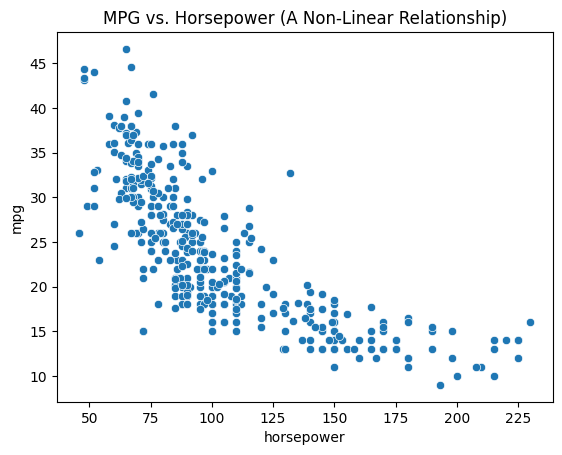

--- Data Statistics (Notice the different scales!) ---
              count         mean         std     min       25%      50%  \
mpg           392.0    23.445918    7.805007     9.0    17.000    22.75   
cylinders     392.0     5.471939    1.705783     3.0     4.000     4.00   
displacement  392.0   194.411990  104.644004    68.0   105.000   151.00   
horsepower    392.0   104.469388   38.491160    46.0    75.000    93.50   
weight        392.0  2977.584184  849.402560  1613.0  2225.250  2803.50   
acceleration  392.0    15.541327    2.758864     8.0    13.775    15.50   
model_year    392.0    75.979592    3.683737    70.0    73.000    76.00   

                   75%     max  
mpg             29.000    46.6  
cylinders        8.000     8.0  
displacement   275.750   455.0  
horsepower     126.000   230.0  
weight        3614.750  5140.0  
acceleration    17.025    24.8  
model_year      79.000    82.0  


In [ ]:
# 1. Load the dataset
# We use seaborn to easily load this classic dataset
df = sns.load_dataset('mpg')

# 2. Clean the data
# The 'horsepower' column has some missing '?' values. We'll drop them.
df = df.dropna()

# 'origin' is categorical, we will drop it for this simple exercise
df = df.drop('origin', axis=1)
# We also drop 'name' as it's just an identifier
df = df.drop('name', axis=1)

# 3. Visualize the non-linear relationship
# This clearly shows that MPG vs. Horsepower is NOT a straight line.
# A simple linear model would struggle.
sns.scatterplot(data=df, x='horsepower', y='mpg')
plt.title("MPG vs. Horsepower (A Non-Linear Relationship)")
plt.show()

# 4. Look at the data's scales
print("--- Data Statistics (Notice the different scales!) ---")
print(df.describe().T)

# 5. Split into Features (X) and Target (y)
X = df.drop('mpg', axis=1)
y = df['mpg']

# 6. Split into Train and Test sets
# We use 'raw' in the name to remember this is the unscaled data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 1. Build the Naive Model
model_naive = Sequential([
    Dense(64, activation='relu', input_dim=X_train_raw.shape[1]),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1) # Output layer (linear)
])

# 2. Compile
model_naive.compile(optimizer='adam',
                    loss='mean_squared_error',
                    metrics=['mae']) # Mean Absolute Error

# 3. Train on RAW data
print("\nTraining Naive Model...")
history_naive = model_naive.fit(
    X_train_raw, y_train,
    epochs=50,
    validation_data=(X_test_raw, y_test),
    verbose=0 # Set to 1 to see epoch-by-epoch
)

# 4. Report final MAE
print("\n--- Naive Model Results ---")
val_loss, val_mae = model_naive.evaluate(X_test_raw, y_test, verbose=0)
print(f"Final Validation MAE: {val_mae:.4f} MPG")


Training Naive Model...

--- Naive Model Results ---
Final Validation MAE: 6.5983 MPG
